---
# Fase 7 — Comparação de Modelos

**Objetivo:** Implementar e comparar múltiplos algoritmos de classificação utilizando **validação cruzada** apenas nos dados de treinamento. O objetivo é identificar os candidatos mais promissores antes de prosseguirmos para o tratamento de desbalanceamento e ajuste de hiperparâmetros.

**Modelos avaliados:**
1. Regressão Logística (Baseline)
2. KNN (K-Nearest Neighbors)
3. SVM (Support Vector Machine)
4. Random Forest
5. XGBoost
6. MLP (Multi-Layer Perceptron)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Carregar dados de treinamento (O teste fica reservado!)
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')['Dataset']

colunas_numericas = list(X_train.columns)

# Importar preprocessors da fase 5
preprocessor_scaled = joblib.load('models/preprocessor_scaled.joblib')
preprocessor_unscaled = joblib.load('models/preprocessor_unscaled.joblib')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def criar_pipeline(modelo, usar_scaler=True):
    if usar_scaler:
        pre = ColumnTransformer(transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), colunas_numericas)
        ])
    else:
        pre = ColumnTransformer(transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median'))
            ]), colunas_numericas)
        ])
    
    return Pipeline(steps=[
        ('preprocessor', pre),
        ('classifier', modelo)
    ])

print('Dados e dependências carregados com sucesso!')

Dados e dependências carregados com sucesso!


## 7.1 — Importação e Configuração dos Modelos

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Instanciar os modelos com parâmetros básicos
modelos = {
    'Regressão Logística': criar_pipeline(
        LogisticRegression(random_state=42, max_iter=1000), 
        usar_scaler=True
    ),
    'KNN': criar_pipeline(
        KNeighborsClassifier(), 
        usar_scaler=True
    ),
    'SVM': criar_pipeline(
        SVC(probability=True, random_state=42), 
        usar_scaler=True
    ),
    'Random Forest': criar_pipeline(
        RandomForestClassifier(random_state=42), 
        usar_scaler=False
    ),
    'XGBoost': criar_pipeline(
        XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), 
        usar_scaler=False
    ),
    'MLP': criar_pipeline(
        MLPClassifier(random_state=42, early_stopping=True, max_iter=1000), 
        usar_scaler=True
    )
}

print(f'{len(modelos)} modelos configurados e prontos para avaliação.')

6 modelos configurados e prontos para avaliação.


## 7.2 — Avaliação via Validação Cruzada (Cross-Validation)

Usaremos o `StratifiedKFold` com 5 splits para garantir que a proporção das classes se mantenha em cada fold.

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados_cv = {}

print('Iniciando avaliação dos modelos (isso pode levar alguns segundos)...\n')

for nome, pipeline in modelos.items():
    print(f'Avaliando: {nome}...')
    scores = cross_validate(
        pipeline, X_train, y_train, 
        cv=cv, scoring=metricas, n_jobs=-1
    )
    resultados_cv[nome] = scores

print('\nAvaliação concluída!')

Iniciando avaliação dos modelos (isso pode levar alguns segundos)...

Avaliando: Regressão Logística...


Avaliando: KNN...


Avaliando: SVM...


Avaliando: Random Forest...


Avaliando: XGBoost...


Avaliando: MLP...



Avaliação concluída!


## 7.3 — Comparação dos Resultados

In [4]:
# Organizar os resultados em um DataFrame
linhas_tabela = []

for nome, scores in resultados_cv.items():
    linha = {'Modelo': nome}
    for metrica in metricas:
        # Pega a média e desvio padrão
        media = scores[f'test_{metrica}'].mean()
        std = scores[f'test_{metrica}'].std()
        linha[metrica.capitalize()] = f'{media:.4f} ± {std:.4f}'
        
        # Guardar valor numérico para plotagem posterior
        linha[f'{metrica}_num'] = media
    linhas_tabela.append(linha)

df_comparacao = pd.DataFrame(linhas_tabela)

# Exibir tabela formatada, ordenada pelo Recall (métrica mais crítica)
df_display = df_comparacao.drop(columns=[col for col in df_comparacao.columns if '_num' in col])
df_display = df_display.set_index('Modelo')
df_display

,Accuracy,Precision,Recall,F1,Roc_auc
Modelo,,,,,
Regressão Logística,0.7232 ± 0.0345,0.7427 ± 0.0164,0.9370 ± 0.0395,0.8284 ± 0.0234,0.7172 ± 0.0201
KNN,0.6566 ± 0.0345,0.7346 ± 0.0255,0.8137 ± 0.0231,0.7720 ± 0.0228,0.6268 ± 0.0298
SVM,0.7124 ± 0.0080,0.7149 ± 0.0069,0.9940 ± 0.0074,0.8316 ± 0.0051,0.6027 ± 0.0239
Random Forest,0.7254 ± 0.0221,0.7732 ± 0.0253,0.8740 ± 0.0383,0.8196 ± 0.0152,0.7268 ± 0.0306
XGBoost,0.7232 ± 0.0147,0.7801 ± 0.0265,0.8559 ± 0.0306,0.8154 ± 0.0089,0.7220 ± 0.0270
MLP,0.7124 ± 0.0165,0.7267 ± 0.0122,0.9579 ± 0.0114,0.8264 ± 0.0099,0.6334 ± 0.0231


## 7.4 — Visualização de Desempenho

Como o **Recall** (capacidade de detectar pacientes doentes) é nossa métrica crítica, vamos visualizar como os modelos se comparam nela, e no **ROC-AUC**.

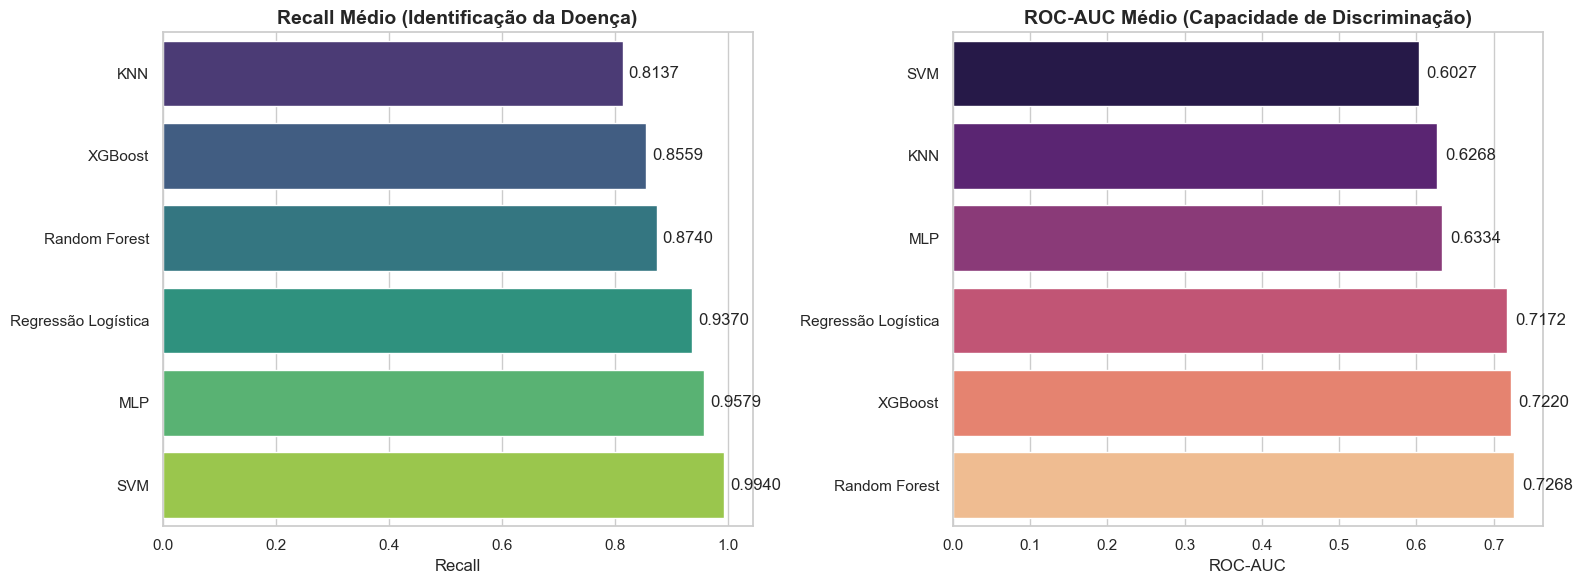

In [5]:
df_plot = df_comparacao.sort_values(by='recall_num', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Recall
sns.barplot(data=df_plot, x='recall_num', y='Modelo', ax=axes[0], palette='viridis')
axes[0].set_title('Recall Médio (Identificação da Doença)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('')
for i, v in enumerate(df_plot['recall_num']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Gráfico de ROC-AUC
df_plot_auc = df_comparacao.sort_values(by='roc_auc_num', ascending=True)
sns.barplot(data=df_plot_auc, x='roc_auc_num', y='Modelo', ax=axes[1], palette='magma')
axes[1].set_title('ROC-AUC Médio (Capacidade de Discriminação)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_ylabel('')
for i, v in enumerate(df_plot_auc['roc_auc_num']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

## 7.5 — Conclusões Iniciais da Fase 7

- O desempenho base de todos os modelos é extraído **sem realizar tratamento de desbalanceamento** (como SMOTE) nem **ajuste de hiperparâmetros**.
- É possível notar que, como a classe `1` (Doença Hepática) é a majoritária (71%), os modelos naturalmente tendem a ter um **Recall** razoável nela. No entanto, o desafio será mantê-lo alto e melhorar a capacidade de distinção real (ROC-AUC e F1-Score).
- A **Regressão Logística** continua sendo um baseline forte, muitas vezes comparável a modelos não-lineares.
- Modelos complexos como **Random Forest** e **XGBoost** podem estar sofrendo de algum overfitting inicial e precisarão de *tuning*.
- A **MLP** exige regularização e possivelmente mais ajustes finos, dado que redes neurais podem ser instáveis com datasets pequenos.
- Na **Fase 8**, investigaremos ativamente se o tratamento do desbalanceamento traz benefícios para estas métricas ou apenas prejudica a performance geral.

### Checklist de Conclusão da Fase 7

- ✅ Todos os 6 modelos implementados via Pipeline.
- ✅ Validação cruzada (Stratified 5-Fold) executada nos dados de treinamento.
- ✅ Métricas (Accuracy, Precision, Recall, F1, ROC-AUC) computadas com média e desvio padrão.
- ✅ Tabela comparativa e gráficos criados.
- ✅ Nenhuma informação do conjunto de Teste foi exposta.
- ✅ Base estabelecida para a próxima fase (Tratamento de Desbalanceamento).